X shape: (500, 400)
logits shape: (500,)
分类标签 y_clf shape: (500,)


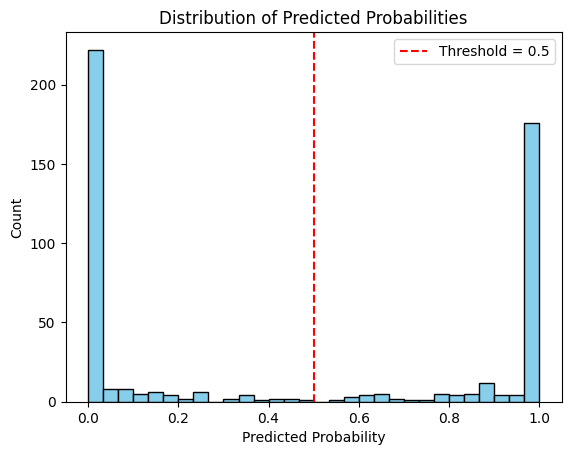

Epoch 0, Loss: 0.6966
Epoch 10, Loss: 0.5126
Epoch 20, Loss: 0.2312
Epoch 30, Loss: 0.0464
Epoch 40, Loss: 0.0076
Epoch 1/20, Loss: 0.7071, Val Loss: 0.6907
Epoch 2/20, Loss: 0.6852, Val Loss: 0.6932
Epoch 3/20, Loss: 0.6670, Val Loss: 0.6956
Epoch 4/20, Loss: 0.6510, Val Loss: 0.6980
Epoch 5/20, Loss: 0.6360, Val Loss: 0.6998
Epoch 6/20, Loss: 0.6209, Val Loss: 0.7009
Epoch 7/20, Loss: 0.6050, Val Loss: 0.7012
Epoch 8/20, Loss: 0.5879, Val Loss: 0.7010
Epoch 9/20, Loss: 0.5695, Val Loss: 0.6999
Epoch 10/20, Loss: 0.5497, Val Loss: 0.6982
Epoch 11/20, Loss: 0.5286, Val Loss: 0.6959
Epoch 12/20, Loss: 0.5061, Val Loss: 0.6932
Epoch 13/20, Loss: 0.4824, Val Loss: 0.6901
Epoch 14/20, Loss: 0.4575, Val Loss: 0.6866
Epoch 15/20, Loss: 0.4314, Val Loss: 0.6829
Epoch 16/20, Loss: 0.4044, Val Loss: 0.6792
Epoch 17/20, Loss: 0.3766, Val Loss: 0.6754
Epoch 18/20, Loss: 0.3482, Val Loss: 0.6718
Epoch 19/20, Loss: 0.3196, Val Loss: 0.6685
Epoch 20/20, Loss: 0.2909, Val Loss: 0.6656
Validation Accu

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split


n_gene = 400
n_samples = 500
X = np.random.normal(0,1,(n_samples,n_gene))

# 分类标签
X_logits = (
    X[:,50:80].sum(axis=1)*1.5 +    # 代谢模块（正相关）
    X[:,300:330].sum(axis=1)*(-2.0) # 信号通路模块（负相关）
)

# sigmoid 转概率
prob = 1 / (1 + np.exp(-X_logits))

# 二分类标签
y_clf = (prob > 0.5).astype(int)

# 打印结果检查
print("X shape:", X.shape)          # (500, 400)
print("logits shape:", X_logits.shape)  # (500,)
print("分类标签 y_clf shape:", y_clf.shape)  # (500,1)

# Step 4: 可视化标签分布
plt.hist(prob, bins=30, color='skyblue', edgecolor='black')
plt.axvline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Distribution of Predicted Probabilities")
plt.legend()
plt.show()

# 数据准备
X_train, X_val, y_train, y_val = train_test_split(X, y_clf, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)


# 定义 MLP 分类器
class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super(MLPClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),  # 输入层 → 隐藏层1
            nn.ReLU(),                  # 激活函数
            nn.Linear(128, 64),         # 隐藏层1 → 隐藏层2
            nn.ReLU(),                  # 激活函数
            nn.Linear(64, 1),           # 隐藏层2 → 输出层
            nn.Sigmoid()                # 输出概率 (0~1)
        )
    def forward(self, x):
        return self.net(x)
    



# 适合初学者的快速理解深度学习的基本流程：前向传播 → 损失 → 反向传播 → 更新
# 数据准备
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y_clf, dtype=torch.float32).reshape(-1, 1)  # 转换为列向量

# 模型、损失函数、优化器
model = MLPClassifier(input_dim=400)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练循环
for epoch in range(50):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


# 初始化模型、损失函数和优化器
model = MLPClassifier(input_dim=n_gene)
criterion = nn.BCELoss()  # 二分类交叉熵损失
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练模型
n_epochs = 20
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    # 验证模型
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
    
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# 评估模型,适合初学者理解模型性能的基本指标：准确率、精确率、召回率和F1分数
model.eval()
with torch.no_grad():
    val_outputs = model(X_val)
    predicted = (val_outputs > 0.5).float()  # 二分类阈值
    accuracy = accuracy_score(y_val, predicted)
    precision = precision_score(y_val, predicted)
    recall = recall_score(y_val, predicted)
    f1 = f1_score(y_val, predicted)
print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Precision: {precision:.4f}")
print(f"Validation Recall: {recall:.4f}")
print(f"Validation F1 Score: {f1:.4f}")


# 适合跟踪每个 epoch 的指标，方便调参和分析模型收敛情况。
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

n_epochs = 20
for epoch in range(n_epochs):
    # 训练
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    # 验证
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
        
        # 将概率转为标签 (0/1)
        val_pred = (val_outputs > 0.5).int()
        
        # 计算性能指标
        acc = accuracy_score(y_val.numpy(), val_pred.numpy())
        precision = precision_score(y_val.numpy(), val_pred.numpy())
        recall = recall_score(y_val.numpy(), val_pred.numpy())
        f1 = f1_score(y_val.numpy(), val_pred.numpy())
    
    print(f"Epoch {epoch+1}/{n_epochs}, "
          f"Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, "
          f"Acc: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")



In [2]:
theta = X.dot(X.T) / n_gene
y_pred = theta.dot(y_clf)
y_pred = (y_pred > 0.5).astype(int)
accuracy = (y_pred == y_clf).mean() 
print(f"基于相关性矩阵的分类准确率: {accuracy:.4f}")

基于相关性矩阵的分类准确率: 0.8340


Epoch 1/20, Train Loss: 0.6971, Val Loss: 0.7033, Acc: 0.4300, F1: 0.6014
Epoch 2/20, Train Loss: 0.6812, Val Loss: 0.6998, Acc: 0.3800, F1: 0.5441
Epoch 3/20, Train Loss: 0.6665, Val Loss: 0.6966, Acc: 0.3800, F1: 0.5156
Epoch 4/20, Train Loss: 0.6520, Val Loss: 0.6934, Acc: 0.4100, F1: 0.5280
Epoch 5/20, Train Loss: 0.6370, Val Loss: 0.6902, Acc: 0.4600, F1: 0.5424
Epoch 6/20, Train Loss: 0.6211, Val Loss: 0.6867, Acc: 0.4900, F1: 0.5321
Epoch 7/20, Train Loss: 0.6041, Val Loss: 0.6830, Acc: 0.5400, F1: 0.5577
Epoch 8/20, Train Loss: 0.5857, Val Loss: 0.6790, Acc: 0.5600, F1: 0.5600
Epoch 9/20, Train Loss: 0.5658, Val Loss: 0.6746, Acc: 0.5900, F1: 0.5773
Epoch 10/20, Train Loss: 0.5442, Val Loss: 0.6697, Acc: 0.5900, F1: 0.5684
Epoch 11/20, Train Loss: 0.5209, Val Loss: 0.6643, Acc: 0.5700, F1: 0.5376
Epoch 12/20, Train Loss: 0.4959, Val Loss: 0.6587, Acc: 0.5800, F1: 0.5435
Epoch 13/20, Train Loss: 0.4695, Val Loss: 0.6528, Acc: 0.5600, F1: 0.5111
Epoch 14/20, Train Loss: 0.4415, V

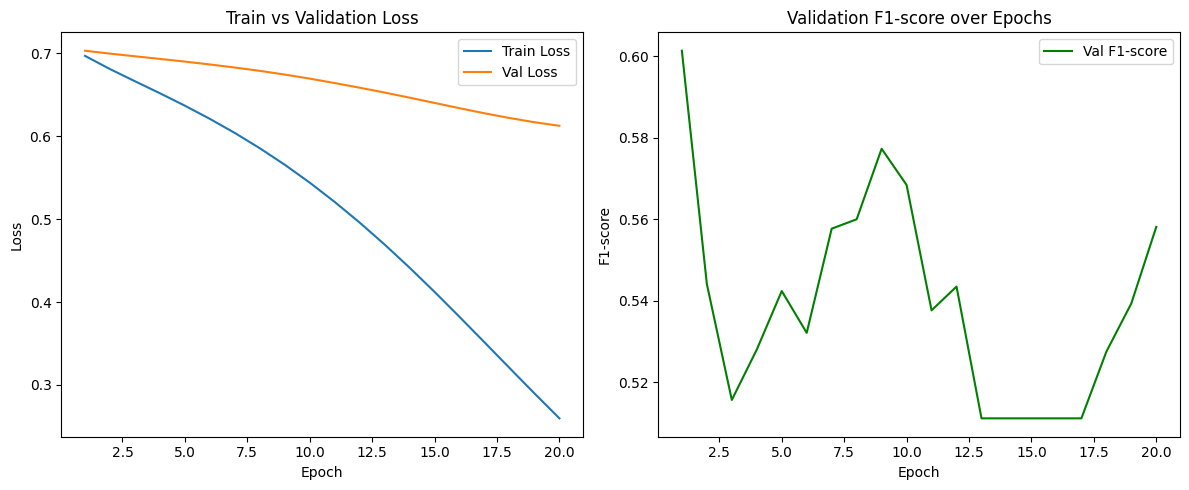

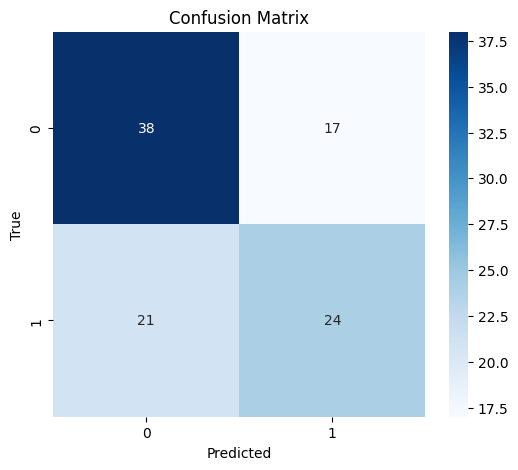

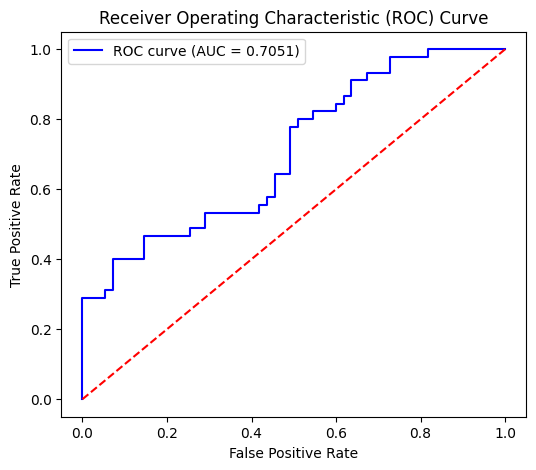

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# 数据生成
n_gene = 400
n_samples = 500
X = np.random.normal(0,1,(n_samples,n_gene))
X_logits = X[:,50:80].sum(axis=1)*1.5 + X[:,300:330].sum(axis=1)*(-2.0)
prob = 1 / (1 + np.exp(-X_logits))
y_clf = (prob > 0.5).astype(int)

# 划分训练/验证集
X_train, X_val, y_train, y_val = train_test_split(X, y_clf, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

# 定义 MLP 分类器
class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super(MLPClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# 初始化模型、损失函数和优化器
model = MLPClassifier(input_dim=n_gene)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 保存指标
train_losses, val_losses, val_accs, val_f1s = [], [], [], []

n_epochs = 20
for epoch in range(n_epochs):
    # 训练
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    # 验证
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
        val_losses.append(val_loss.item())
        
        val_pred = (val_outputs > 0.5).int()
        acc = accuracy_score(y_val.numpy(), val_pred.numpy())
        f1 = f1_score(y_val.numpy(), val_pred.numpy())
        val_accs.append(acc)
        val_f1s.append(f1)
    
    print(f"Epoch {epoch+1}/{n_epochs}, "
          f"Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, "
          f"Acc: {acc:.4f}, F1: {f1:.4f}")

# 绘制曲线
plt.figure(figsize=(12,5))

# 损失曲线
plt.subplot(1,2,1)
plt.plot(range(1,n_epochs+1), train_losses, label="Train Loss")
plt.plot(range(1,n_epochs+1), val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()

# F1-score 曲线
plt.subplot(1,2,2)
plt.plot(range(1,n_epochs+1), val_f1s, label="Val F1-score", color="green")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("Validation F1-score over Epochs")
plt.legend()

plt.tight_layout()
plt.show()


# 绘制 混淆矩阵，查看分类错误的分布
from sklearn.metrics import confusion_matrix
import seaborn as sns
model.eval()
with torch.no_grad():
    val_outputs = model(X_val)
    val_pred = (val_outputs > 0.5).int()
cm = confusion_matrix(y_val.numpy(), val_pred.numpy())
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


# ROC 曲线和 AUC 分数，评估模型在不同阈值下的性能
from sklearn.metrics import roc_curve, auc
model.eval()
with torch.no_grad():
    val_outputs = model(X_val).numpy()
fpr, tpr, thresholds = roc_curve(y_val.numpy(), val_outputs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()



from sklearn.metrics import r2_score

# 标签改为连续值
y_reg = prob
X_train, X_val, y_train, y_val = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

# 定义 MLP 回归器（去掉 Sigmoid）
class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super(MLPRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)   # 输出连续值
        )
    def forward(self, x):
        return self.net(x)
    
# 训练函数
def train_model(loss_fn, n_epochs=20):
    model = MLPRegressor(input_dim=n_gene)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_losses, val_losses, val_r2 = [], [], []
    
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = loss_fn(outputs, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

Epoch 1/20, Train Loss: 0.4023, Val Loss: 0.3268, R²: -0.5177
Epoch 2/20, Train Loss: 0.3137, Val Loss: 0.2809, R²: -0.3045
Epoch 3/20, Train Loss: 0.2466, Val Loss: 0.2470, R²: -0.1471
Epoch 4/20, Train Loss: 0.1973, Val Loss: 0.2248, R²: -0.0442
Epoch 5/20, Train Loss: 0.1623, Val Loss: 0.2133, R²: 0.0093
Epoch 6/20, Train Loss: 0.1394, Val Loss: 0.2098, R²: 0.0259
Epoch 7/20, Train Loss: 0.1251, Val Loss: 0.2104, R²: 0.0226
Epoch 8/20, Train Loss: 0.1148, Val Loss: 0.2115, R²: 0.0177
Epoch 9/20, Train Loss: 0.1042, Val Loss: 0.2105, R²: 0.0223
Epoch 10/20, Train Loss: 0.0914, Val Loss: 0.2069, R²: 0.0392
Epoch 11/20, Train Loss: 0.0767, Val Loss: 0.2016, R²: 0.0636
Epoch 12/20, Train Loss: 0.0618, Val Loss: 0.1959, R²: 0.0902
Epoch 13/20, Train Loss: 0.0481, Val Loss: 0.1908, R²: 0.1140
Epoch 14/20, Train Loss: 0.0367, Val Loss: 0.1867, R²: 0.1330
Epoch 15/20, Train Loss: 0.0280, Val Loss: 0.1839, R²: 0.1459
Epoch 16/20, Train Loss: 0.0218, Val Loss: 0.1822, R²: 0.1538
Epoch 17/20, 

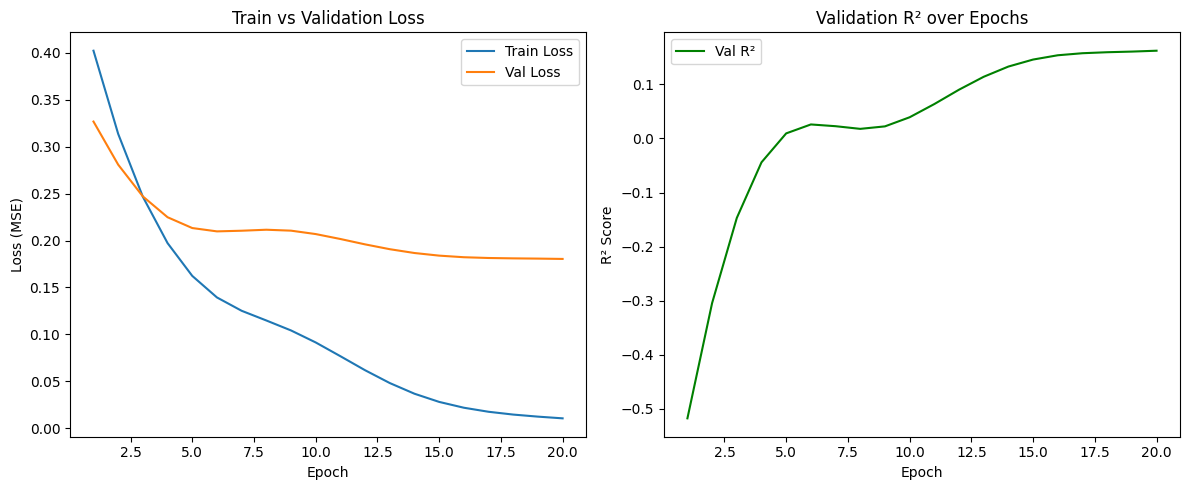

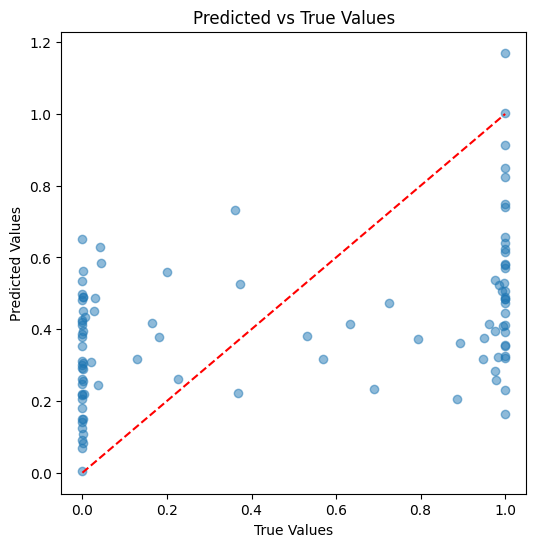

Validation MSE: 0.1804
Validation R² Score: 0.1622
Training with MSE Loss:
Epoch 1/20, Train Loss: 0.6292, Val Loss: 0.5241, R²: -1.4341
Epoch 2/20, Train Loss: 0.5072, Val Loss: 0.4503, R²: -1.0913
Epoch 3/20, Train Loss: 0.4096, Val Loss: 0.3882, R²: -0.8029
Epoch 4/20, Train Loss: 0.3310, Val Loss: 0.3369, R²: -0.5648
Epoch 5/20, Train Loss: 0.2680, Val Loss: 0.2958, R²: -0.3737
Epoch 6/20, Train Loss: 0.2179, Val Loss: 0.2643, R²: -0.2276
Epoch 7/20, Train Loss: 0.1788, Val Loss: 0.2417, R²: -0.1227
Epoch 8/20, Train Loss: 0.1492, Val Loss: 0.2275, R²: -0.0563
Epoch 9/20, Train Loss: 0.1282, Val Loss: 0.2205, R²: -0.0238
Epoch 10/20, Train Loss: 0.1148, Val Loss: 0.2188, R²: -0.0163
Epoch 11/20, Train Loss: 0.1069, Val Loss: 0.2200, R²: -0.0219
Epoch 12/20, Train Loss: 0.1017, Val Loss: 0.2216, R²: -0.0292
Epoch 13/20, Train Loss: 0.0963, Val Loss: 0.2217, R²: -0.0295
Epoch 14/20, Train Loss: 0.0889, Val Loss: 0.2195, R²: -0.0195
Epoch 15/20, Train Loss: 0.0790, Val Loss: 0.2153, R

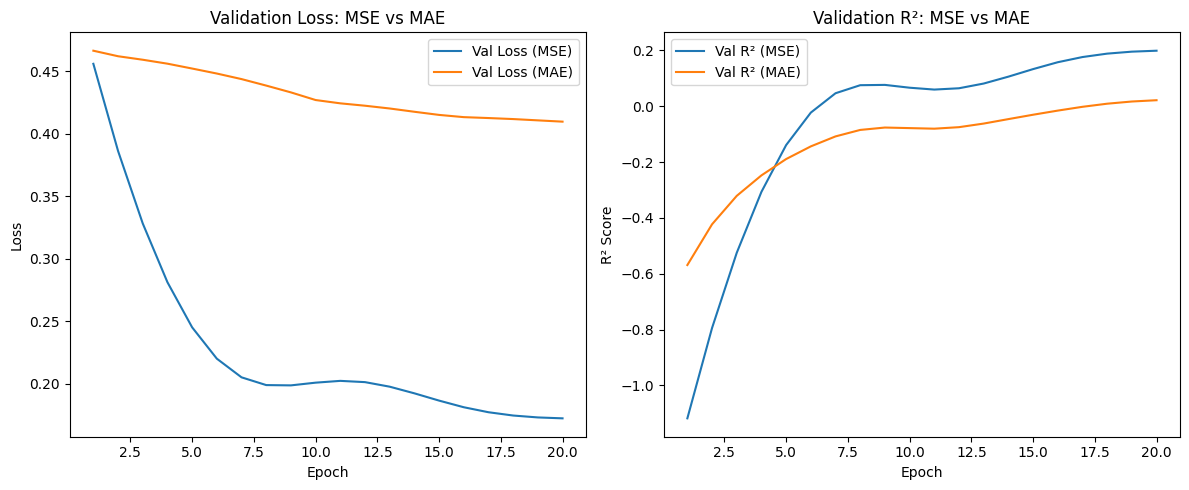

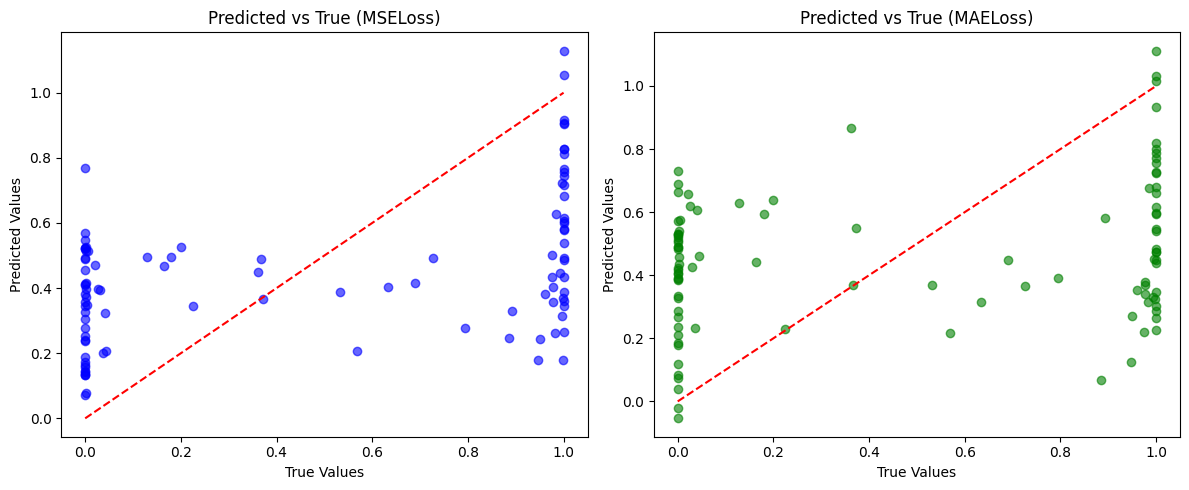

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 数据生成
n_gene = 400
n_samples = 500
X = np.random.normal(0,1,(n_samples,n_gene))
X_logits = X[:,50:80].sum(axis=1)*1.5 + X[:,300:330].sum(axis=1)*(-2.0)
prob = 1 / (1 + np.exp(-X_logits))   # 连续概率作为回归目标
y_reg = prob   # 回归标签

# 划分训练/验证集
X_train, X_val, y_train, y_val = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

# 定义 MLP 回归器
class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super(MLPRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)   # 输出连续值，不加 Sigmoid
        )
    def forward(self, x):
        return self.net(x)

# 初始化模型、损失函数和优化器
model = MLPRegressor(input_dim=n_gene)
criterion = nn.MSELoss()   # 回归任务常用 MSE
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 保存指标
train_losses, val_losses, val_r2 = [], [], []

n_epochs = 20
for epoch in range(n_epochs):
    # 训练
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    # 验证
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
        val_losses.append(val_loss.item())
        
        # 计算 R²
        r2 = r2_score(y_val.numpy(), val_outputs.numpy())
        val_r2.append(r2)
    
    print(f"Epoch {epoch+1}/{n_epochs}, "
          f"Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, R²: {r2:.4f}")

# 绘制曲线
plt.figure(figsize=(12,5))

# 损失曲线
plt.subplot(1,2,1)
plt.plot(range(1,n_epochs+1), train_losses, label="Train Loss")
plt.plot(range(1,n_epochs+1), val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Train vs Validation Loss")
plt.legend()

# R² 曲线
plt.subplot(1,2,2)
plt.plot(range(1,n_epochs+1), val_r2, label="Val R²", color="green")
plt.xlabel("Epoch")
plt.ylabel("R² Score")
plt.title("Validation R² over Epochs")
plt.legend()

plt.tight_layout()
plt.show()


# 绘制预测 vs 真实值的散点图，查看回归效果
model.eval()
with torch.no_grad():
    val_outputs = model(X_val).numpy()
plt.figure(figsize=(6,6))
plt.scatter(y_val.numpy(), val_outputs, alpha=0.5)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # 理想情况下的对角线
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True Values")
plt.show()


# 适合初学者理解回归模型的基本评估方法：均方误差（MSE）和 R² 分数。
model.eval()
with torch.no_grad():
    val_outputs = model(X_val).numpy()
mse = mean_squared_error(y_val.numpy(), val_outputs)
r2 = r2_score(y_val.numpy(), val_outputs)
print(f"Validation MSE: {mse:.4f}")
print(f"Validation R² Score: {r2:.4f}")

# 定义训练函数，返回模型和指标
def train_model(loss_fn, n_epochs=20):
    model = MLPRegressor(input_dim=n_gene)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_losses, val_losses, val_r2 = [], [], []
    
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = loss_fn(outputs, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = loss_fn(val_outputs, y_val)
            val_losses.append(val_loss.item())
            r2 = r2_score(y_val.numpy(), val_outputs.numpy())
            val_r2.append(r2)
        print(f"Epoch {epoch+1}/{n_epochs}, "
              f"Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, R²: {r2:.4f}")  
    
    return model, train_losses, val_losses, val_r2

# 使用 MSE 训练模型
print("Training with MSE Loss:")
model_mse, train_mse, val_mse, r2_mse = train_model(nn.MSELoss())

# 使用 MAE 训练模型
print("\nTraining with MAE Loss:")
model_mae, train_mae, val_mae, r2_mae = train_model(nn.L1Loss())
        
# 使用 MSE 训练模型
print("Training with MSE Loss:")
model_mse, train_mse, val_mse, r2_mse = train_model(nn.MSELoss())

# 使用 MAE 训练模型
print("\nTraining with MAE Loss:")
model_mae, train_mae, val_mae, r2_mae = train_model(nn.L1Loss())


# 绘制对比曲线
plt.figure(figsize=(12,5))

# 损失对比
plt.subplot(1,2,1)
plt.plot(range(1,21), val_mse, label="Val Loss (MSE)")
plt.plot(range(1,21), val_mae, label="Val Loss (MAE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss: MSE vs MAE")
plt.legend()

# R² 对比
plt.subplot(1,2,2)
plt.plot(range(1,21), r2_mse, label="Val R² (MSE)")
plt.plot(range(1,21), r2_mae, label="Val R² (MAE)")
plt.xlabel("Epoch")
plt.ylabel("R² Score")
plt.title("Validation R²: MSE vs MAE")
plt.legend()

plt.tight_layout()
plt.show()

# 绘制预测值 vs 真实值散点图
model_mse.eval()
with torch.no_grad():
    pred_mse = model_mse(X_val).numpy()

model_mae.eval()
with torch.no_grad():
    pred_mae = model_mae(X_val).numpy()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_val.numpy(), pred_mse, alpha=0.6, color="blue")
plt.plot([0,1],[0,1], 'r--')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True (MSELoss)")

plt.subplot(1,2,2)
plt.scatter(y_val.numpy(), pred_mae, alpha=0.6, color="green")
plt.plot([0,1],[0,1], 'r--')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True (MAELoss)")

plt.tight_layout()
plt.show()


# 残差分析，查看模型预测误差的分布情况
residuals_mse = y_val.numpy() - pred_mse.flatten()
residuals_mae = y_val.numpy() - pred_mae.flatten()
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)

# MSE 残差直方图
plt.subplot(1,2,1)
plt.hist(residuals_mse, bins=30, alpha=0.7, color="blue")
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residuals (True - Predicted)")
plt.ylabel("Count")
plt.title("Residuals Distribution (MSELoss)")

# MAE 残差直方图
plt.subplot(1,2,2)
plt.hist(residuals_mae, bins=30, alpha=0.7, color="green")
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residuals (True - Predicted)")
plt.ylabel("Count")
plt.title("Residuals Distribution (MAELoss)")

plt.tight_layout()
plt.show()




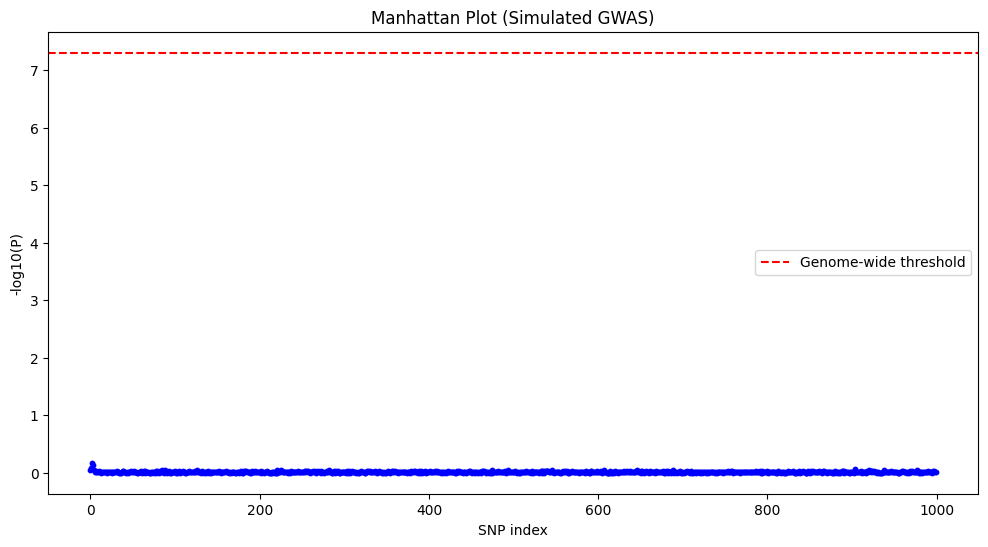

         SNP      Beta         P
2      SNP_2  1.223906  0.668058
3      SNP_3 -1.001855  0.726324
1      SNP_1 -0.709034  0.813234
903  SNP_903  0.456262  0.877827
920  SNP_920  0.428085  0.888452
688  SNP_688 -0.442325  0.889200
0      SNP_0  0.416356  0.892048
493  SNP_493 -0.408990  0.893811
126  SNP_126 -0.402192  0.894576
88    SNP_88  0.396238  0.898625


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import t

# 模拟 SNP 数据
n_samples = 500
n_snps = 1000
np.random.seed(42)
genotypes = np.random.randint(0, 3, size=(n_samples, n_snps))  # 0/1/2

# 模拟表型：假设前 5 个 SNP 对表型有影响
true_effects = np.zeros(n_snps)
true_effects[:5] = [0.5, -0.8, 1.2, -1.0, 0.7]  # 前 5 个 SNP 有效应
phenotype = genotypes @ true_effects + np.random.normal(0, 2, n_samples)

# 单标记线性回归
p_values = []
betas = []
for j in range(n_snps):
    X = genotypes[:, j].reshape(-1, 1)
    y = phenotype
    model = LinearRegression().fit(X, y)
    beta = model.coef_[0]
    betas.append(beta)

     # 计算 t 统计量和 p 值
    y_pred = model.predict(X)
    residuals = y - y_pred
    sse = np.sum(residuals**2)
    se_beta = np.sqrt(sse / (n_samples-2)) / np.std(X)
    t_stat = beta / se_beta
    p_val = 2 * (1 - t.cdf(np.abs(t_stat), df=n_samples-2))
    p_values.append(p_val)
    

# 整理结果
results = pd.DataFrame({
    "SNP": [f"SNP_{i}" for i in range(n_snps)],
    "Beta": betas,
    "P": p_values
})

# 绘制 Manhattan plot
plt.figure(figsize=(12,6))
plt.scatter(range(n_snps), -np.log10(results["P"]), c="blue", s=10)
plt.axhline(-np.log10(5e-8), color="red", linestyle="--", label="Genome-wide threshold")
plt.xlabel("SNP index")
plt.ylabel("-log10(P)")
plt.title("Manhattan Plot (Simulated GWAS)")
plt.legend()
plt.show()

# 输出前 10 个最显著 SNP
print(results.sort_values("P").head(10))

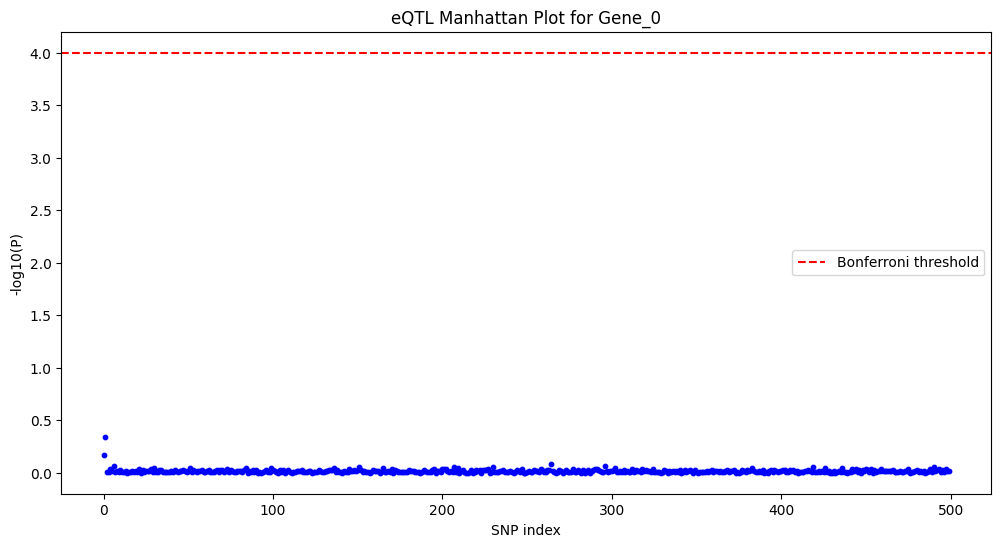

         SNP      Beta         P
1      SNP_1 -1.104225  0.452560
0      SNP_0  0.731771  0.672737
264  SNP_264 -0.373431  0.828836
296  SNP_296  0.297883  0.865274
6      SNP_6  0.292552  0.867095
207  SNP_207  0.286378  0.872534
230  SNP_230  0.259896  0.881556
151  SNP_151 -0.259624  0.882872
490  SNP_490 -0.251304  0.886929
419  SNP_419 -0.238883  0.889847


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import t

# 模拟数据
np.random.seed(42)
n_samples = 300
n_snps = 500
n_genes = 10

# 基因型矩阵 (0/1/2)
genotypes = np.random.randint(0, 3, size=(n_samples, n_snps))

# 基因表达矩阵 (连续值)
expressions = np.random.normal(0, 1, size=(n_samples, n_genes))

# 假设 SNP_0 和 SNP_1 影响 Gene_0 的表达
expressions[:,0] += 0.8*genotypes[:,0] - 1.2*genotypes[:,1]

# 单标记线性回归：检测每个 SNP 与 Gene_0 的关联
p_values = []
betas = []
for j in range(n_snps):
    X = genotypes[:, j].reshape(-1, 1)
    y = expressions[:,0]
    model = LinearRegression().fit(X, y)
    beta = model.coef_[0]
    betas.append(beta)
    
    # 计算 t 统计量和 p 值
    y_pred = model.predict(X)
    residuals = y - y_pred
    sse = np.sum(residuals**2)
    se_beta = np.sqrt(sse / (n_samples-2)) / np.std(X)
    t_stat = beta / se_beta
    p_val = 2 * (1 - t.cdf(np.abs(t_stat), df=n_samples-2))
    p_values.append(p_val)

# 整理结果
results = pd.DataFrame({
    "SNP": [f"SNP_{i}" for i in range(n_snps)],
    "Beta": betas,
    "P": p_values
})

# 绘制 Manhattan plot
plt.figure(figsize=(12,6))
plt.scatter(range(n_snps), -np.log10(results["P"]), c="blue", s=10)
plt.axhline(-np.log10(0.05/n_snps), color="red", linestyle="--", label="Bonferroni threshold")
plt.xlabel("SNP index")
plt.ylabel("-log10(P)")
plt.title("eQTL Manhattan Plot for Gene_0")
plt.legend()
plt.show()

# 输出前 10 个最显著 SNP
print(results.sort_values("P").head(10))



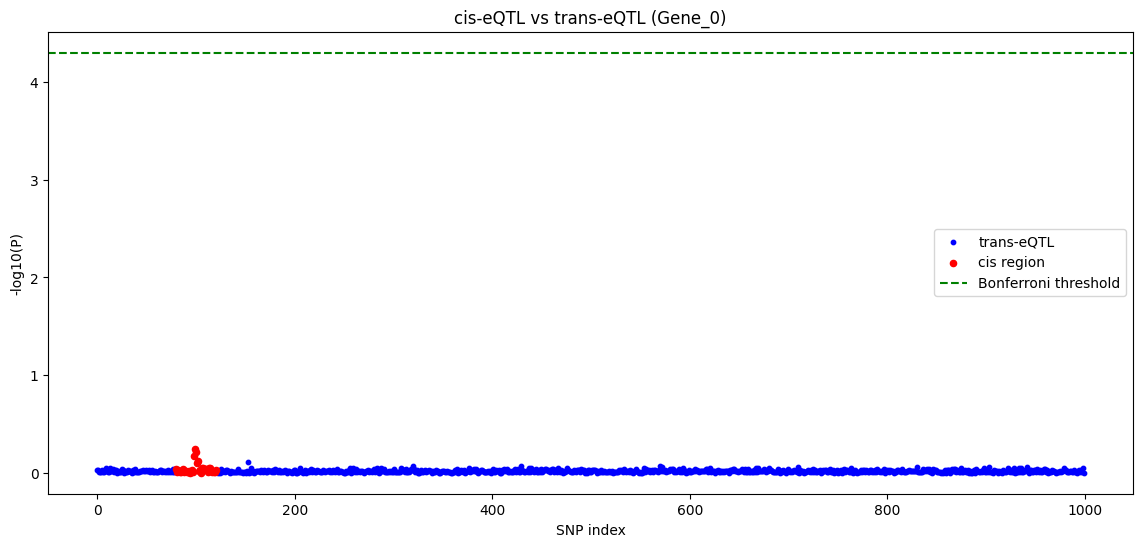

Top cis-eQTL SNPs:
        SNP      Beta         P
19   SNP_99 -1.093897  0.577453
20  SNP_100  1.010899  0.611578
18   SNP_98  0.826763  0.678077
22  SNP_102  0.665553  0.753612
21  SNP_101 -0.547700  0.800826
34  SNP_114  0.291474  0.888942
33  SNP_113 -0.298384  0.896948
27  SNP_107  0.281081  0.901819
26  SNP_106 -0.277962  0.902513
7    SNP_87 -0.248322  0.908727

Top trans-eQTL SNPs:
         SNP      Beta         P
99    SNP_99 -1.093897  0.577453
100  SNP_100  1.010899  0.611578
98    SNP_98  0.826763  0.678077
102  SNP_102  0.665553  0.753612
152  SNP_152  0.598115  0.779234
101  SNP_101 -0.547700  0.800826
570  SNP_570  0.392967  0.852130
320  SNP_320 -0.392387  0.855525
429  SNP_429 -0.392683  0.856522
710  SNP_710 -0.362786  0.871796


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import t

np.random.seed(42)
n_samples = 300
n_snps = 1000
n_genes = 5

# 基因型矩阵 (0/1/2)
genotypes = np.random.randint(0, 3, size=(n_samples, n_snps))

# 基因表达矩阵 (连续值)
expressions = np.random.normal(0, 1, size=(n_samples, n_genes))

# 假设 Gene_0 受 SNP_100 附近的 SNP 影响 (cis 区域 ±20)
cis_index = 100
cis_range = 20
for offset, coef in zip(range(-2, 3), [0.8, -1.0, 1.2, -0.7, 0.5]):
    snp_idx = cis_index + offset
    expressions[:,0] += coef * genotypes[:, snp_idx]

# 定义函数：单标记线性回归
def single_snp_regression(genotypes, expression):
    betas, p_values = [], []
    for j in range(genotypes.shape[1]):
        X = genotypes[:, j].reshape(-1, 1)
        y = expression
        model = LinearRegression().fit(X, y)
        beta = model.coef_[0]
        betas.append(beta)
        
        y_pred = model.predict(X)
        residuals = y - y_pred
        sse = np.sum(residuals**2)
        se_beta = np.sqrt(sse / (n_samples-2)) / np.std(X)
        t_stat = beta / se_beta
        p_val = 2 * (1 - t.cdf(np.abs(t_stat), df=n_samples-2))
        p_values.append(p_val)
    return betas, p_values

# trans-eQTL: 全基因组范围
betas_trans, pvals_trans = single_snp_regression(genotypes, expressions[:,0])
results_trans = pd.DataFrame({
    "SNP": [f"SNP_{i}" for i in range(n_snps)],
    "Beta": betas_trans,
    "P": pvals_trans
})

# cis-eQTL: 只检测邻近 SNP
cis_snps = range(cis_index - cis_range, cis_index + cis_range + 1)
betas_cis, pvals_cis = single_snp_regression(genotypes[:,cis_snps], expressions[:,0])
results_cis = pd.DataFrame({
    "SNP": [f"SNP_{i}" for i in cis_snps],
    "Beta": betas_cis,
    "P": pvals_cis
})

# 绘制 Manhattan plot 对比
plt.figure(figsize=(14,6))
plt.scatter(range(n_snps), -np.log10(results_trans["P"]), c="blue", s=10, label="trans-eQTL")
plt.scatter(list(cis_snps), -np.log10(results_trans.loc[cis_snps,"P"]), c="red", s=20, label="cis region")
plt.axhline(-np.log10(0.05/n_snps), color="green", linestyle="--", label="Bonferroni threshold")
plt.xlabel("SNP index")
plt.ylabel("-log10(P)")
plt.title("cis-eQTL vs trans-eQTL (Gene_0)")
plt.legend()
plt.show()

# 输出 cis 区域最显著 SNP
print("Top cis-eQTL SNPs:")
print(results_cis.sort_values("P").head(10))

# 输出全基因组最显著 SNP
print("\nTop trans-eQTL SNPs:")
print(results_trans.sort_values("P").head(10))


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy.stats import t

np.random.seed(42)
n_samples = 300
n_snps = 200
n_genes = 5

# 基因型矩阵 (0/1/2)
genotypes = np.random.randint(0, 3, size=(n_samples, n_snps))

# 基因表达矩阵 (连续值)
expressions = np.random.normal(0, 1, size=(n_samples, n_genes))

# 设定每个基因受不同 SNP 区域影响
effect_regions = {
    0: [10, 11, 12],   # Gene_0 受 SNP_10-12 影响
    1: [50, 51, 52],   # Gene_1 受 SNP_50-52 影响
    2: [100, 101, 102],# Gene_2 受 SNP_100-102 影响
    3: [150, 151, 152],# Gene_3 受 SNP_150-152 影响
    4: [180, 181, 182] # Gene_4 受 SNP_180-182 影响
}

for gene, snps in effect_regions.items():
    for idx, coef in zip(snps, [1.0, -0.8, 1.2]):
        expressions[:,gene] += coef * genotypes[:,idx]

        
# 单标记线性回归函数
def single_snp_regression(genotypes, expression):
    p_values = []
    for j in range(genotypes.shape[1]):
        X = genotypes[:, j].reshape(-1, 1)
        y = expression
        model = LinearRegression().fit(X, y)
        beta = model.coef_[0]
        y_pred = model.predict(X)
        residuals = y - y_pred
        sse = np.sum(residuals**2)
        se_beta = np.sqrt(sse / (n_samples-2)) / np.std(X)
        t_stat = beta / se_beta
        p_val = 2 * (1 - t.cdf(np.abs(t_stat), df=n_samples-2))
        p_values.append(p_val)
    return p_values

# 计算所有基因的 p 值矩阵
p_matrix = np.zeros((n_genes, n_snps))
for g in range(n_genes):
    p_matrix[g,:] = single_snp_regression(genotypes, expressions[:,g])

# 转换为 -log10(P)
logp_matrix = -np.log10(p_matrix)

# 绘制热图
plt.figure(figsize=(12,6))
sns.heatmap(logp_matrix, cmap="viridis", cbar_kws={'label': '-log10(P)'})
plt.xlabel("SNP index")
plt.ylabel("Gene index")
plt.title("Multi-gene eQTL Mapping Heatmap")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

np.random.seed(42)
n_samples = 500
n_snps = 200

# 1. 模拟基因型矩阵 (0/1/2)
genotypes = np.random.randint(0, 3, size=(n_samples, n_snps))

# 2. 模拟基因表达 (暴露)
# 假设 Gene_0 表达受 SNP_10-12 影响
expr = np.random.normal(0, 1, n_samples)
expr += 0.8*genotypes[:,10] - 1.0*genotypes[:,11] + 1.2*genotypes[:,12]

# 3. 模拟结局表型 (结果)
# 假设结局受 Gene_0 表达影响
outcome = 0.5*expr + np.random.normal(0, 1, n_samples)

# 4. eQTL 映射：SNP → Gene_0 表达
betas_exposure, ses_exposure = [], []
for j in range(n_snps):
    X = genotypes[:, j].reshape(-1,1)
    y = expr
    model = LinearRegression().fit(X,y)
    beta = model.coef_[0]
    y_pred = model.predict(X)
    residuals = y - y_pred
    se = np.std(residuals)/np.sqrt(n_samples)
    betas_exposure.append(beta)
    ses_exposure.append(se)



# 5. GWAS 映射：SNP → Outcome
betas_outcome, ses_outcome = [], []
for j in range(n_snps):
    X = genotypes[:, j].reshape(-1,1)
    y = outcome
    model = LinearRegression().fit(X,y)
    beta = model.coef_[0]
    y_pred = model.predict(X)
    residuals = y - y_pred
    se = np.std(residuals)/np.sqrt(n_samples)
    betas_outcome.append(beta)
    ses_outcome.append(se)


# 6. MR 分析 (IVW & Egger)
bx = np.array(betas_exposure)
by = np.array(betas_outcome)
sx = np.array(ses_exposure)
sy = np.array(ses_outcome)

# IVW
weights = 1/sy**2
ivw_beta = np.sum(weights*by/bx)/np.sum(weights)
print("IVW causal estimate:", ivw_beta)



# Egger 回归
X = sm.add_constant(bx)
egger_model = sm.WLS(by, X, weights=1/sy**2).fit()
print("Egger causal estimate (slope):", egger_model.params[1])
print("Egger intercept:", egger_model.params[0])

Hello world!
Hello world!
Hello world!
Hello world!
Hello world!


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

np.random.seed(42)
n_samples = 500
n_snps = 300
n_genes = 2   # 两个基因作为暴露

# 1. 模拟基因型矩阵 (0/1/2)
genotypes = np.random.randint(0, 3, size=(n_samples, n_snps))

# 2. 模拟基因表达
expr1 = np.random.normal(0, 1, n_samples) + 1.0*genotypes[:,10] - 0.8*genotypes[:,11]
expr2 = np.random.normal(0, 1, n_samples) + 1.2*genotypes[:,50] - 1.0*genotypes[:,51]

# 3. 模拟结局表型 (结果受两个基因表达影响)
outcome = 0.6*expr1 + 0.4*expr2 + np.random.normal(0, 1, n_samples)
                                                   
                                                   
# 4. GWAS 映射：SNP → Outcome
betas_outcome, ses_outcome = [], []
for j in range(n_snps):
    X = genotypes[:, j].reshape(-1,1)
    y = outcome
    model = LinearRegression().fit(X,y)
    beta = model.coef_[0]
    y_pred = model.predict(X)
    residuals = y - y_pred
    se = np.std(residuals)/np.sqrt(n_samples)
    betas_outcome.append(beta)
    ses_outcome.append(se)

# 5. eQTL 映射：SNP → Gene 表达
betas_expr1, betas_expr2 = [], []
for j in range(n_snps):
    X = genotypes[:, j].reshape(-1,1)
    betas_expr1.append(LinearRegression().fit(X, expr1).coef_[0])
    betas_expr2.append(LinearRegression().fit(X, expr2).coef_[0])

# 6. 多变量 MR (MVMR)
bx = np.vstack([betas_expr1, betas_expr2]).T   # SNP → 暴露 (两个基因)
by = np.array(betas_outcome)                  # SNP → 结局
weights = 1/np.array(ses_outcome)**2

# 加权回归：Outcome ~ Expr1 + Expr2
X = sm.add_constant(bx)
mvmr_model = sm.WLS(by, X, weights=weights).fit()

print("MVMR causal estimates:")
print("Intercept:", mvmr_model.params[0])
print("Gene1 effect:", mvmr_model.params[1])
print("Gene2 effect:", mvmr_model.params[2])

MVMR causal estimates:
Intercept: 0.0013352402441916258
Gene1 effect: 0.530473743178182
Gene2 effect: 0.41821025242930965


真实效应: [0.6, 0.4, 0.3, 0.2, 0.1]
MVMR估计值:
        MR_Estimate
Gene_0     0.709610
Gene_1     0.413200
Gene_2     0.251456
Gene_3     0.219919
Gene_4     0.104883


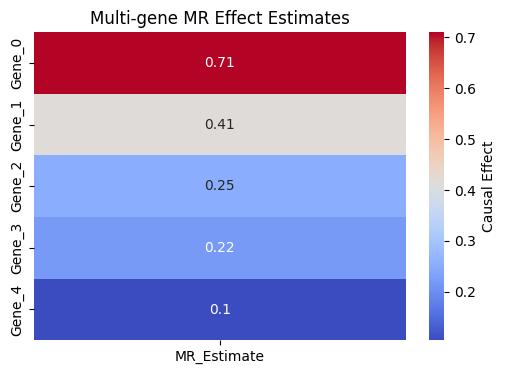

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
n_samples = 500
n_snps = 300
n_genes = 5   # 多个基因作为暴露

# 1. 模拟基因型矩阵
genotypes = np.random.randint(0, 3, size=(n_samples, n_snps))

# 2. 模拟多个基因表达，每个基因受不同 SNP 影响
expressions = []
effect_snps = [[10,11], [50,51], [100,101], [150,151], [200,201]]
effect_coefs = [[1.0,-0.8], [1.2,-1.0], [0.9,-0.7], [1.1,-1.2], [0.8,-0.6]]

for snps, coefs in zip(effect_snps, effect_coefs):
    expr = np.random.normal(0,1,n_samples)
    for idx, coef in zip(snps, coefs):
        expr += coef * genotypes[:,idx]
    expressions.append(expr)
expressions = np.array(expressions).T  # shape (samples, genes)

# 3. 模拟结局表型 (结果受多个基因表达影响)
true_effects = [0.6, 0.4, 0.3, 0.2, 0.1]  # 真实因果效应
outcome = expressions @ np.array(true_effects) + np.random.normal(0,1,n_samples)

# 4. GWAS 映射：SNP → Outcome
betas_outcome, ses_outcome = [], []
for j in range(n_snps):
    X = genotypes[:, j].reshape(-1,1)
    y = outcome
    model = LinearRegression().fit(X,y)
    beta = model.coef_[0]
    y_pred = model.predict(X)
    residuals = y - y_pred
    se = np.std(residuals)/np.sqrt(n_samples)
    betas_outcome.append(beta)
    ses_outcome.append(se)

# 5. eQTL 映射：SNP → Gene 表达
betas_expr = []
for g in range(n_genes):
    betas_g = []
    for j in range(n_snps):
        X = genotypes[:, j].reshape(-1,1)
        betas_g.append(LinearRegression().fit(X, expressions[:,g]).coef_[0])
    betas_expr.append(betas_g)
bx = np.array(betas_expr).T   # shape (snps, genes)
by = np.array(betas_outcome)
weights = 1/np.array(ses_outcome)**2

# 6. 多变量 MR (MVMR)
X = sm.add_constant(bx)
mvmr_model = sm.WLS(by, X, weights=weights).fit()

# 提取估计值
estimates = mvmr_model.params[1:]  # 每个基因的因果效应估计
df_estimates = pd.DataFrame(estimates, index=[f"Gene_{i}" for i in range(n_genes)], columns=["MR_Estimate"])


print("真实效应:", true_effects)
print("MVMR估计值:")
print(df_estimates)

# 7. 绘制热图
plt.figure(figsize=(6,4))
sns.heatmap(df_estimates, annot=True, cmap="coolwarm", cbar_kws={'label':'Causal Effect'})
plt.title("Multi-gene MR Effect Estimates")
plt.show()

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split

np.random.seed(42)
torch.manual_seed(42)

n_samples = 500
n_snps = 300

# 模拟基因型矩阵
genotypes = np.random.randint(0, 3, size=(n_samples, n_snps))

# 模拟基因表达
expr1 = np.random.normal(0, 1, n_samples) + 1.0*genotypes[:,10] - 0.8*genotypes[:,11]
expr2 = np.random.normal(0, 1, n_samples) + 1.2*genotypes[:,50] - 1.0*genotypes[:,51]

# 模拟结局表型
outcome = 0.6*expr1 + 0.4*expr2 + np.random.normal(0, 1, n_samples)

# 单标记线性回归
p_values = []
betas = []
for j in range(n_snps):
    X = genotypes[:, j].reshape(-1, 1)
    y = phenotype
    model = LinearRegression().fit(X, y)
    beta = model.coef_[0]
    betas.append(beta)
    
    # 计算 t 统计量和 p 值
    y_pred = model.predict(X)
    residuals = y - y_pred
    sse = np.sum(residuals**2)
    se_beta = np.sqrt(sse / (n_samples-2)) / np.std(X)
    t_stat = beta / se_beta
    p_val = 2 * (1 - t.cdf(np.abs(t_stat), df=n_samples-2))
    p_values.append(p_val)

# 6. eQTL 映射：SNP → Gene 表达
betas_expr1, betas_expr2 = [], []
for j in range(n_snps):
    X = genotypes[:, j].reshape(-1,1)
    betas_expr1.append(LinearRegression().fit(X, expr1).coef_[0])
    betas_expr2.append(LinearRegression().fit(X, expr2).coef_[0])



# 7. 多变量 MR (未校正 PC1)
bx = np.vstack([betas_expr1, betas_expr2]).T
by = np.array(betas_outcome)
weights = 1/np.array(ses_outcome)**2
X = sm.add_constant(bx)
mvmr_model = sm.WLS(by, X, weights=weights).fit()

print("MVMR (未校正PC1):")
print("Gene1 effect:", mvmr_model.params[1])
print("Gene2 effect:", mvmr_model.params[2])


# 8. 多变量 MR (校正 PC1)
# 在真实场景里，PC1 会作为协变量加入回归模型
X_pc = sm.add_constant(np.column_stack([bx, pc1]))
mvmr_model_pc = sm.WLS(by, X_pc, weights=weights).fit()

print("\nMVMR (校正PC1):")
print("Gene1 effect:", mvmr_model_pc.params[1])
print("Gene2 effect:", mvmr_model_pc.params[2])
print("PC1 effect:", mvmr_model_pc.params[3])




In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split

np.random.seed(42)
torch.manual_seed(42)

n_samples = 500
n_snps = 300

# 模拟基因型矩阵
genotypes = np.random.randint(0, 3, size=(n_samples, n_snps))


# 模拟基因表达
expr1 = np.random.normal(0, 1, n_samples) + 1.0*genotypes[:,10] - 0.8*genotypes[:,11]
expr2 = np.random.normal(0, 1, n_samples) + 1.2*genotypes[:,50] - 1.0*genotypes[:,51]

# 模拟结局表型
outcome = 0.6*expr1 + 0.4*expr2 + np.random.normal(0, 1, n_samples)

# 转换为张量
X = torch.tensor(genotypes, dtype=torch.float32)
y_expr1 = torch.tensor(expr1, dtype=torch.float32).unsqueeze(1)
y_expr2 = torch.tensor(expr2, dtype=torch.float32).unsqueeze(1)
y_outcome = torch.tensor(outcome, dtype=torch.float32).unsqueeze(1)


# 定义神经网络
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)